In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/kaggle/input/allflowmeter-hikari2021/ALLFLOWMETER_HIKARI2021.csv")

In [3]:
print(df.isnull().sum().sum())

0


In [4]:
df.head()

,Unnamed: 0.1,Unnamed: 0,uid,originh,originp,responh,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,...,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,traffic_category,Label
0,0,0,Cg61Jch3vdz9DBptj,103.255.15.23,13316,128.199.242.104,443,2.207588,15,14,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,29200,65160,0,Bruteforce-XML,1
1,1,1,CdRIlqLWdj35Y9vW9,103.255.15.23,13318,128.199.242.104,443,15.624266,15,14,...,1.534300e+07,1.534300e+07,1.534300e+07,1.534300e+07,0.0,29200,65160,0,Bruteforce-XML,1
2,2,2,CLzp9Khd0Y09Qkgrg,103.255.15.23,13320,128.199.242.104,443,12.203357,14,13,...,1.196814e+07,1.196814e+07,1.196814e+07,1.196814e+07,0.0,29200,65160,0,Bruteforce-XML,1
3,3,3,Cnf1YA4iLB4CSNWB88,103.255.15.23,13322,128.199.242.104,443,9.992448,14,13,...,9.759205e+06,9.759205e+06,9.759205e+06,9.759205e+06,0.0,29200,65160,0,Bruteforce-XML,1
4,4,4,C4ZKvv3fpO72EAOsJ6,103.255.15.23,13324,128.199.242.104,443,7.780611,14,14,...,7.545305e+06,7.545305e+06,7.545305e+06,7.545305e+06,0.0,29200,65160,0,Bruteforce-XML,1


In [5]:
print(df['traffic_category'].unique())

['Bruteforce-XML' 'Bruteforce' 'Background' 'Benign' 'Probing'
 'XMRIGCC CryptoMiner']


In [7]:
print(df.columns)

Index(['Unnamed: 0.1', 'Unnamed: 0', 'uid', 'originh', 'originp', 'responh',
       'responp', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot',
       'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec',
       'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio',
       'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max',
       'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max',
       'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count',
       'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count',
       'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count',
       'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max',
       'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std',
       'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot',
       'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min',
       'flow_pkts_payload.max'

# Load dataset

In [8]:
X = df.drop(columns=["Label", "traffic_category", "uid", "originh", "responh","Unnamed: 0.1", "Unnamed: 0"], errors="ignore")

X = X.dropna()
kept_indices = X.index
# Removes rows with ANY missing value in feature columns
# TinyML models cannot handle NaN
# Quantization (INT8) fails with NaNs
# Stores the indices of rows that survived dropna()

y = df.loc[kept_indices, "traffic_category"]

print(X.shape)
print(y.shape)

(555278, 81)
(555278,)


# Import

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from collections import Counter

# Encode Labels and One-Hot

In [22]:
print("\nValue of y:")
print(y)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

print("\n🔹 Label Encoding Map (Index → Class Name):")
for i, cls in enumerate(le.classes_):
    print(f"{i} → {cls}")
# print(y_encoded.value_counts())

print("\nValue of y_encoded:")
print(y_encoded)

y_categorical = to_categorical(y_encoded, num_classes=num_classes)
print("\nValue of y_categorical:")
print(y_categorical)


Value of y:
0              Bruteforce-XML
1              Bruteforce-XML
2              Bruteforce-XML
3              Bruteforce-XML
4              Bruteforce-XML
                 ...         
555273    XMRIGCC CryptoMiner
555274    XMRIGCC CryptoMiner
555275    XMRIGCC CryptoMiner
555276    XMRIGCC CryptoMiner
555277    XMRIGCC CryptoMiner
Name: traffic_category, Length: 555278, dtype: object

🔹 Label Encoding Map (Index → Class Name):
0 → Background
1 → Benign
2 → Bruteforce
3 → Bruteforce-XML
4 → Probing
5 → XMRIGCC CryptoMiner

Value of y_encoded:
[3 3 3 ... 5 5 5]

Value of y_categorical:
[[0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 ...
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1.]]


# Standardize Features and Apply PCA

In [23]:
print("\nValue of X:")
print(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nValue of X_scaled:")
print(X_scaled)

pca = PCA()
pca.fit(X_scaled)
cumulative_variance = pca.explained_variance_ratio_.cumsum()
n_components_95 = (cumulative_variance < 0.95).sum() + 1
print(f"Number of PCA components for 95% variance: {n_components_95}")

pca_final = PCA(n_components=n_components_95)
X_pca = pca_final.fit_transform(X_scaled)
X_pca = X_pca.reshape((X_pca.shape[0], X_pca.shape[1], 1))
print("\nValue of X_pca:")
print(X_pca)

print(X_pca.shape)
print(y_categorical.shape)
# print(X_pca)


Value of X:
        originp  responp  flow_duration  fwd_pkts_tot  bwd_pkts_tot  \
0         13316      443       2.207588            15            14   
1         13318      443      15.624266            15            14   
2         13320      443      12.203357            14            13   
3         13322      443       9.992448            14            13   
4         13324      443       7.780611            14            14   
...         ...      ...            ...           ...           ...   
555273      138      138       0.000000             1             0   
555274      138      138       0.000000             1             0   
555275      138      138       0.000000             1             0   
555276      138      138       0.000000             1             0   
555277      138      138       0.000000             1             0   

        fwd_data_pkts_tot  bwd_data_pkts_tot  fwd_pkts_per_sec  \
0                       6                  6          6.794746   
1 

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train class counts:", Counter(np.argmax(y_train, axis=1)))
print("Test class counts:", Counter(np.argmax(y_test, axis=1)))

Train class counts: Counter({np.int64(1): 277945, np.int64(0): 136121, np.int64(4): 18710, np.int64(2): 4707, np.int64(3): 4116, np.int64(5): 2623})
Test class counts: Counter({np.int64(1): 69486, np.int64(0): 34030, np.int64(4): 4678, np.int64(2): 1177, np.int64(3): 1029, np.int64(5): 656})


# Build CNN Model
Key Points About CNN Approach CNN is good for sequential/structured data where local patterns matter. You had to reshape the data to 3D for Conv1D. PCA helped reduce feature dimensions before feeding to CNN. Training can take longer than tree-based models like Random Forest

In [25]:
model = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(n_components_95, 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 25, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        12,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,646 (49.40 KB)

 Trainable params: 12,646 (49.40 KB)

 Non-trainable params: 0 (0.00 B)

# Define EarlyStopping

In [26]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    verbose=1,
    restore_best_weights=True
)

# Train model


In [27]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop]
)

val_acc = history.history['val_accuracy']
best_epoch = np.argmax(val_acc) + 1
best_val_acc = val_acc[best_epoch - 1]

print(f"\nTraining stopped at epoch {len(val_acc)}")
print(f"Optimal epoch: {best_epoch}, Validation Accuracy: {best_val_acc:.4f}")


Epoch 1/50
11106/11106 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.6936 - loss: 0.6239 - val_accuracy: 0.7175 - val_loss: 0.5564
Epoch 2/50
11106/11106 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.7243 - loss: 0.5474 - val_accuracy: 0.7286 - val_loss: 0.5319
Epoch 3/50
11106/11106 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.7287 - loss: 0.5346 - val_accuracy: 0.7301 - val_loss: 0.5263
Epoch 4/50
11106/11106 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.7308 - loss: 0.5266 - val_accuracy: 0.7337 - val_loss: 0.5195
Epoch 5/50
11106/11106 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.7343 - loss: 0.5216 - val_accuracy: 0.7317 - val_loss: 0.5248
Epoch 6/50
11106/11106 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.7353 - loss: 0.5198 - val_accuracy: 0.7356 - val_loss: 0.5145
Epoch 7/50
11106/11106 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.7370 - loss: 0.5166 - val_accuracy: 0.7386 - val_loss: 0.5124
Epoch 8/50
11106/11106 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 

# Evaluate Mode

3471/3471 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step

Test Accuracy: 0.748217115689382


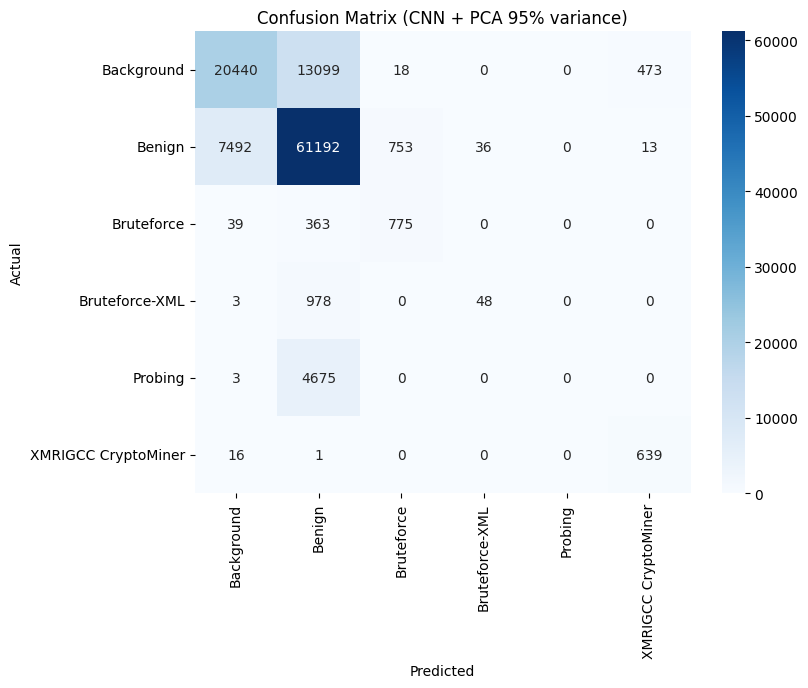


Classification Report:
                     precision    recall  f1-score   support

         Background       0.73      0.60      0.66     34030
             Benign       0.76      0.88      0.82     69486
         Bruteforce       0.50      0.66      0.57      1177
     Bruteforce-XML       0.57      0.05      0.09      1029
            Probing       0.00      0.00      0.00      4678
XMRIGCC CryptoMiner       0.57      0.97      0.72       656

           accuracy                           0.75    111056
          macro avg       0.52      0.53      0.47    111056
       weighted avg       0.71      0.75      0.72    111056



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

print("\nTest Accuracy:", accuracy_score(y_test_labels, y_pred))

cm = confusion_matrix(y_test_labels, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (CNN + PCA 95% variance)")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred, target_names=le.classes_))

# Plot of Training Progress

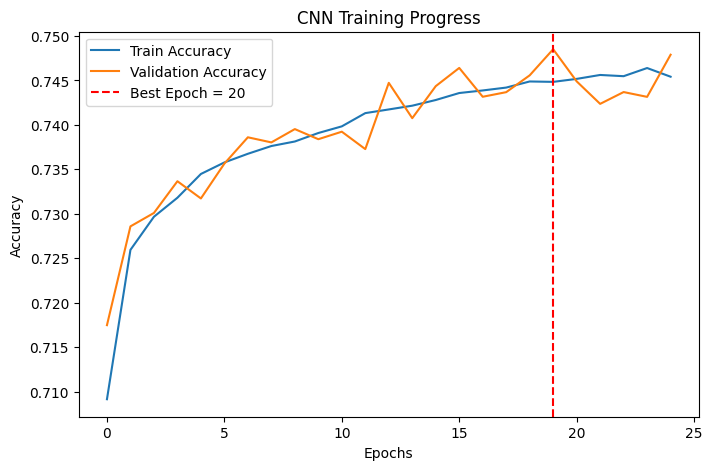

In [31]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.axvline(best_epoch-1, color='r', linestyle='--', label=f'Best Epoch = {best_epoch}')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("CNN Training Progress")
plt.show()

# PCA Components

In [32]:
feature_names = X.columns

loadings = pca_final.components_
n_components = pca_final.n_components_

# Show top 5 features contributing to each component
for i in range(n_components):
    component_loadings = loadings[i]

    top_indices = np.argsort(np.abs(component_loadings))[::-1][:5]
    top_features = feature_names[top_indices]
    top_values = component_loadings[top_indices]

    print(f"\nTop features contributing to PC{i+1}:")
    for f, v in zip(top_features, top_values):
        print(f" {f}: {v:.4f}")



Top features contributing to PC1:
 flow_FIN_flag_count: 0.2073
 bwd_header_size_max: 0.2049
 flow_pkts_payload.std: 0.1981
 bwd_pkts_payload.std: 0.1960
 bwd_init_window_size: 0.1928

Top features contributing to PC2:
 idle.max: 0.2356
 flow_iat.max: 0.2352
 fwd_iat.max: 0.2348
 idle.avg: 0.2332
 fwd_iat.std: 0.2214

Top features contributing to PC3:
 bwd_PSH_flag_count: 0.2077
 bwd_pkts_tot: 0.2012
 bwd_data_pkts_tot: 0.2010
 flow_ACK_flag_count: 0.2005
 bwd_header_size_tot: 0.2003

Top features contributing to PC4:
 bwd_pkts_per_sec: 0.3160
 flow_pkts_per_sec: 0.3141
 responp: 0.3081
 fwd_last_window_size: 0.3037
 fwd_pkts_per_sec: 0.2981

Top features contributing to PC5:
 fwd_subflow_bytes: 0.3181
 fwd_data_pkts_tot: 0.3102
 fwd_PSH_flag_count: 0.3090
 fwd_pkts_payload.tot: 0.2790
 active.min: 0.2594

Top features contributing to PC6:
 fwd_iat.min: 0.3385
 flow_iat.min: 0.3383
 flow_iat.avg: 0.3248
 fwd_iat.avg: 0.3130
 responp: 0.1717

Top features contributing to PC7:
 fwd_iat.m

# RandomForest

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from imblearn.over_sampling import SMOTE
from collections import Counter

In [3]:
df = pd.read_csv("/kaggle/input/allflowmeter-hikari2021/ALLFLOWMETER_HIKARI2021.csv")

X = df.drop(columns=["Label", "traffic_category", "uid", "originh", "responh",
                     "Unnamed: 0.1", "Unnamed: 0"], errors="ignore")

X = X.fillna(0)

kept_indices = X.index
y = df.loc[kept_indices, "traffic_category"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

class_counts = Counter(y_encoded)
print(class_counts)

print("\n🔹 Label Encoding Map (Index → Class Name):")
for i, cls in enumerate(le.classes_):
    print(f"{i} → {cls}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Counter({np.int64(1): 347431, np.int64(0): 170151, np.int64(4): 23388, np.int64(2): 5884, np.int64(3): 5145, np.int64(5): 3279})

🔹 Label Encoding Map (Index → Class Name):
0 → Background
1 → Benign
2 → Bruteforce
3 → Bruteforce-XML
4 → Probing
5 → XMRIGCC CryptoMiner


In [4]:
# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y_encoded)

print("\nAfter SMOTE class distribution:")
print(Counter(y_resampled))


After SMOTE class distribution:
Counter({np.int64(3): 347431, np.int64(2): 347431, np.int64(0): 347431, np.int64(1): 347431, np.int64(4): 347431, np.int64(5): 347431})


In [5]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

print("Train class counts:", Counter(y_train))
print("Test class counts:", Counter(y_test))

Train class counts: Counter({np.int64(1): 277945, np.int64(2): 277945, np.int64(5): 277945, np.int64(0): 277945, np.int64(3): 277944, np.int64(4): 277944})
Test class counts: Counter({np.int64(4): 69487, np.int64(3): 69487, np.int64(2): 69486, np.int64(5): 69486, np.int64(0): 69486, np.int64(1): 69486})


In [8]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=10,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Evaluate Model
y_pred = rf.predict(X_test)
print("✅ Test Accuracy:", accuracy_score(y_test, y_pred))

✅ Test Accuracy: 0.9143716510201046


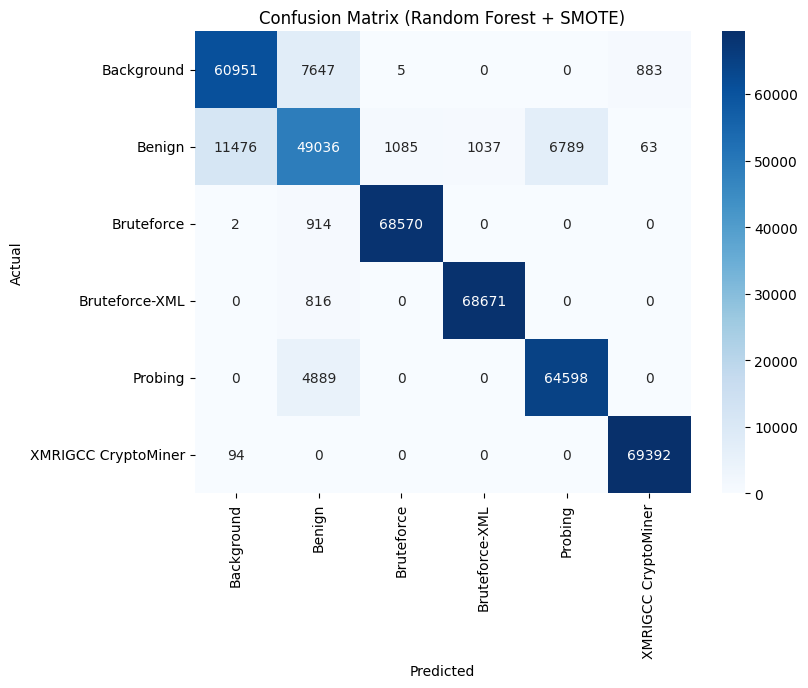


Classification Report:
                     precision    recall  f1-score   support

         Background       0.84      0.88      0.86     69486
             Benign       0.77      0.71      0.74     69486
         Bruteforce       0.98      0.99      0.99     69486
     Bruteforce-XML       0.99      0.99      0.99     69487
            Probing       0.90      0.93      0.92     69487
XMRIGCC CryptoMiner       0.99      1.00      0.99     69486

           accuracy                           0.91    416918
          macro avg       0.91      0.91      0.91    416918
       weighted avg       0.91      0.91      0.91    416918

Done


In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Random Forest + SMOTE)")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("Done")

# XG Boost

In [27]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [28]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=num_classes,
    random_state=42,
    n_jobs=-1
)

In [29]:
xgb.fit(X_train, y_train)

# Predict
y_pred = xgb.predict(X_test)
print(y_pred)

[4 2 5 ... 5 4 4]


In [17]:
# Evaluation
print("XGBoost Test Accuracy:", accuracy_score(y_test, y_pred))

XGBoost Test Accuracy: 0.9101957699115893


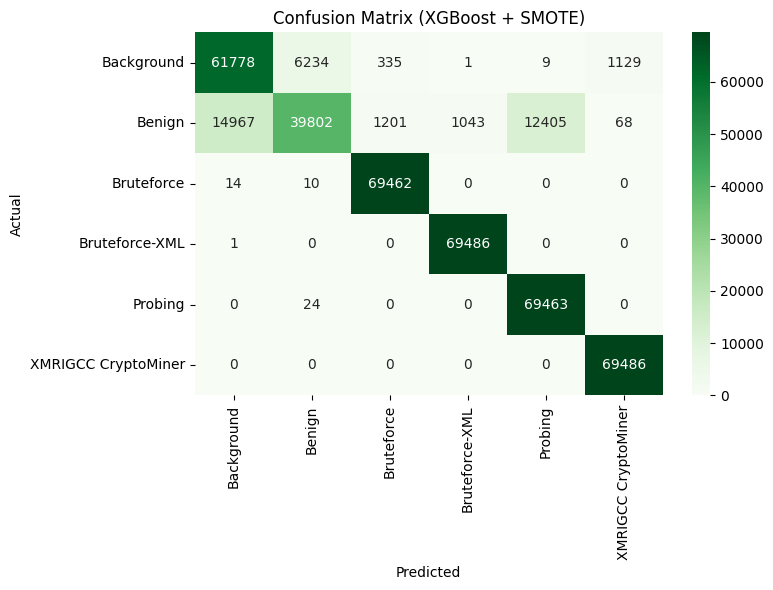

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",          # Optional: different color for XGBoost
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (XGBoost + SMOTE)")
plt.tight_layout()
plt.show()


In [21]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Classification Report:
                     precision    recall  f1-score   support

         Background       0.80      0.89      0.84     69486
             Benign       0.86      0.57      0.69     69486
         Bruteforce       0.98      1.00      0.99     69486
     Bruteforce-XML       0.99      1.00      0.99     69487
            Probing       0.85      1.00      0.92     69487
XMRIGCC CryptoMiner       0.98      1.00      0.99     69486

           accuracy                           0.91    416918
          macro avg       0.91      0.91      0.90    416918
       weighted avg       0.91      0.91      0.90    416918



# Logistic regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Test Accuracy: 0.8588403475023866


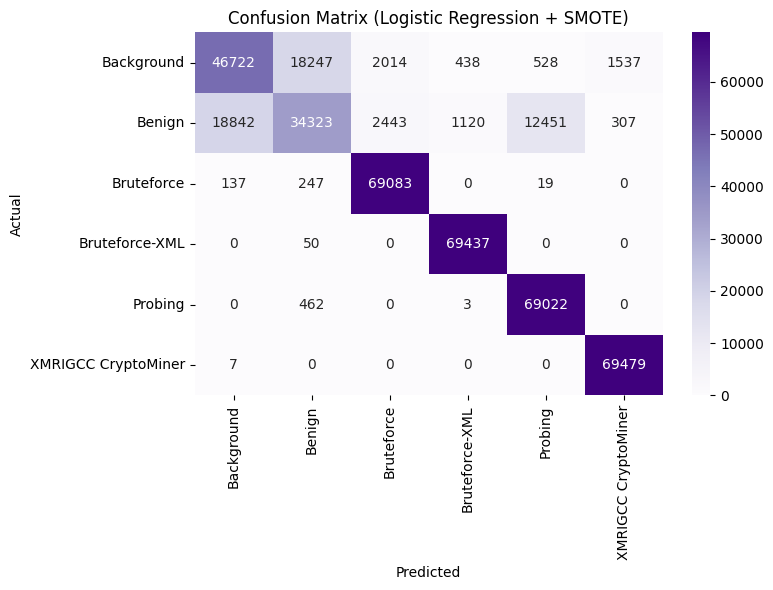


Classification Report:
                     precision    recall  f1-score   support

         Background       0.71      0.67      0.69     69486
             Benign       0.64      0.49      0.56     69486
         Bruteforce       0.94      0.99      0.97     69486
     Bruteforce-XML       0.98      1.00      0.99     69487
            Probing       0.84      0.99      0.91     69487
XMRIGCC CryptoMiner       0.97      1.00      0.99     69486

           accuracy                           0.86    416918
          macro avg       0.85      0.86      0.85    416918
       weighted avg       0.85      0.86      0.85    416918



In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Train Logistic Regression model
lr = LogisticRegression(
    max_iter=50,                 # ensure convergence
    multi_class="multinomial",     # true multiclass logistic regression
    solver="lbfgs",
    n_jobs=-1
)

lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)

# Accuracy
print("Logistic Regression Test Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Logistic Regression + SMOTE)")
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
